Using device: cuda
Using device: cuda
Epoch [1/25] Train Loss: 1.7126 Train Acc: 37.09% Test Acc: 49.81%
Epoch [2/25] Train Loss: 1.3593 Train Acc: 50.54% Test Acc: 60.80%
Epoch [3/25] Train Loss: 1.2076 Train Acc: 56.50% Test Acc: 66.41%
Epoch [4/25] Train Loss: 1.1231 Train Acc: 59.81% Test Acc: 67.46%
Epoch [5/25] Train Loss: 1.0548 Train Acc: 62.88% Test Acc: 70.91%
Epoch [6/25] Train Loss: 1.0148 Train Acc: 64.22% Test Acc: 70.49%
Epoch [7/25] Train Loss: 0.9744 Train Acc: 65.57% Test Acc: 74.11%
Epoch [8/25] Train Loss: 0.9457 Train Acc: 66.89% Test Acc: 73.58%
Epoch [9/25] Train Loss: 0.9105 Train Acc: 68.12% Test Acc: 74.50%
Epoch [10/25] Train Loss: 0.8917 Train Acc: 68.98% Test Acc: 73.80%
Epoch [11/25] Train Loss: 0.8314 Train Acc: 71.15% Test Acc: 77.94%
Epoch [12/25] Train Loss: 0.8161 Train Acc: 71.46% Test Acc: 76.67%
Epoch [13/25] Train Loss: 0.8056 Train Acc: 72.01% Test Acc: 77.62%
Epoch [14/25] Train Loss: 0.7886 Train Acc: 72.74% Test Acc: 77.71%
Epoch [15/25] Train

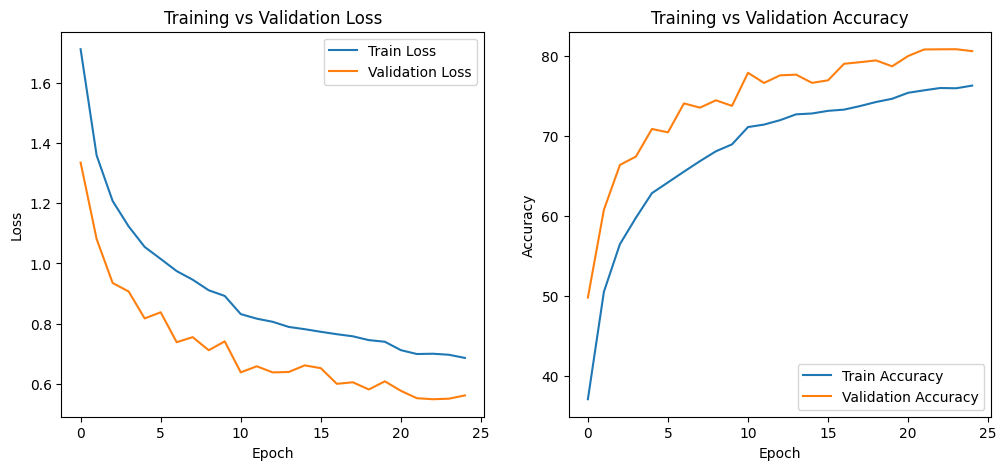

In [2]:

# =====================================
# 1. Import Libraries
# =====================================
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# =====================================
# 2. Device Configuration
# =====================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =====================================
# 3. Data Preprocessing + Augmentation
# =====================================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# =====================================
# 4. Load Dataset
# =====================================
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

# =====================================
# 5. DataLoader
# =====================================
batch_size = 128

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# =====================================
# 6. CNN Model
# =====================================
class ImprovedCNN(nn.Module):

    def __init__(self):
        super(ImprovedCNN, self).__init__()

        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        self.classifier = nn.Sequential(

            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 10)
        )

    def forward(self, x):

        x = self.features(x)

        x = x.view(x.size(0), -1)

        x = self.classifier(x)

        return x


model = ImprovedCNN().to(device)

# =====================================
# 7. Loss + Optimizer
# =====================================
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=10,
    gamma=0.5
)

# =====================================
# 8. Training
# =====================================
epochs = 25

train_losses = []
train_accuracies = []

test_losses = []
test_accuracies = []

for epoch in range(epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    # ==========================
    # Validation / Testing
    # ==========================
    model.eval()

    correct = 0
    total = 0
    running_test_loss = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_test_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_accuracy = 100 * correct / total
    test_loss = running_test_loss / len(test_loader)

    test_losses.append(test_loss)
    test_accuracies.append(test_accuracy)

    scheduler.step()

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.2f}% "
        f"Test Acc: {test_accuracy:.2f}%"
    )

# =====================================
# 9. Final Results
# =====================================
print("\nFinal Test Accuracy:", test_accuracy)
print("Final Test Loss:", test_loss)

# =====================================
# 10. Visualization
# =====================================
plt.figure(figsize=(12,5))

# Loss Curve
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Accuracy Curve
plt.subplot(1,2,2)
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()